<a href="https://colab.research.google.com/github/rafaelrochaplay/geomodelagem/blob/main/(Parte%203)03_analise_integrada_acai(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 3 — Análise integrada entre clima, produção de açaí e visão computacional

Este notebook corresponde à etapa de integração dos resultados do trabalho **Geomodelagem, Clima e Produção de Açaí**.

A análise combina:

1. os mapas e médias climáticas sazonais gerados na Parte 1;
2. os resultados da detecção de cachos de açaí e barbeiros obtidos na Parte 2;
3. uma tabela comparativa sazonal com precipitação, temperatura, umidade, vento e índice exploratório de produção.

A análise é apresentada como uma aplicação acadêmica de geomodelagem e inteligência artificial. Os resultados não devem ser interpretados como comprovação de causalidade direta entre clima, produção agrícola e presença do vetor.

## 1. Preparação do ambiente

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files

# Organização dos diretórios de saída
PASTA_RESULTADOS = Path("resultados")
PASTA_TABELAS = PASTA_RESULTADOS / "tabelas"
PASTA_GRAFICOS = PASTA_RESULTADOS / "graficos"

PASTA_TABELAS.mkdir(parents=True, exist_ok=True)
PASTA_GRAFICOS.mkdir(parents=True, exist_ok=True)

# Ordem usada na apresentação dos resultados
ORDEM_ESTACOES = ["Verão", "Outono", "Inverno", "Primavera"]

## 2. Leitura das médias climáticas sazonais

O arquivo `medias_sazonais_clima.csv` foi produzido na Parte 1 a partir dos dados ERA5-Land processados para a região produtora de açaí no Estado do Pará.

Nesta etapa, o arquivo é enviado ao ambiente de execução do Colab para compor a tabela integrada.

In [2]:
uploaded = files.upload()

nome_arquivo_clima = next(iter(uploaded))
clima = pd.read_csv(nome_arquivo_clima)

clima

Saving medias_sazonais_clima.csv to medias_sazonais_clima.csv


,estacao,precipitacao_media_15h_mm_h,precipitacao_amostras_total_mm,temperatura_media_15h_c,umidade_relativa_media_15h_pct,vento_medio_15h_ms
0,Verão,0.438638,35.014065,29.965771,68.961678,2.083987
1,Outono,0.921793,74.390305,29.365915,76.321800,1.372010
2,Inverno,0.037879,3.056932,32.581966,50.146259,1.954189
3,Primavera,0.008813,0.703508,35.005493,40.330654,2.416888


## 3. Padronização da tabela climática

As colunas geradas na Parte 1 são renomeadas para facilitar a montagem da tabela comparativa final.

In [3]:
clima = clima.rename(columns={
    "estacao": "Estação",
    "precipitacao_media_15h_mm_h": "Precipitação",
    "temperatura_media_15h_c": "Temperatura",
    "umidade_relativa_media_15h_pct": "Umidade",
    "vento_medio_15h_ms": "Vento"
})

clima = clima[[
    "Estação",
    "Precipitação",
    "Temperatura",
    "Umidade",
    "Vento"
]].copy()

clima["Estação"] = pd.Categorical(
    clima["Estação"],
    categories=ORDEM_ESTACOES,
    ordered=True
)

clima = clima.sort_values("Estação").reset_index(drop=True)

clima.round(3)

,Estação,Precipitação,Temperatura,Umidade,Vento
0,Verão,0.439,29.966,68.962,2.084
1,Outono,0.922,29.366,76.322,1.372
2,Inverno,0.038,32.582,50.146,1.954
3,Primavera,0.009,35.005,40.331,2.417


## 4. Construção do índice climático exploratório de produção

O trabalho solicita uma tabela comparativa contendo variáveis climáticas e um índice de produção. Como não há uma série temporal oficial de produtividade agrícola associada às mesmas datas, municípios e horários dos dados climáticos, foi construído um índice climático exploratório.

O índice considera quatro componentes:

- precipitação, com contribuição positiva;
- umidade relativa, com contribuição positiva;
- temperatura, com maior pontuação para valores próximos de 27 °C;
- vento, com menor pontuação para valores relativamente mais intensos.

A expressão usada foi:

\[
I = 0{,}35P + 0{,}30U + 0{,}25T + 0{,}10V
\]

onde \(P\), \(U\), \(T\) e \(V\) são as pontuações normalizadas de precipitação, umidade, temperatura e vento.

Esse índice não representa uma medida real de produção agrícola. Ele serve para comparar, de forma exploratória, quais estações apresentaram condições climáticas relativamente mais favoráveis segundo os critérios definidos.

In [4]:
def normalizar_minmax(serie):
    minimo = serie.min()
    maximo = serie.max()

    if np.isclose(minimo, maximo):
        return pd.Series(0.5, index=serie.index)

    return (serie - minimo) / (maximo - minimo)


dados = clima.copy()

dados["precip_norm"] = normalizar_minmax(dados["Precipitação"])
dados["umidade_norm"] = normalizar_minmax(dados["Umidade"])

temperatura_referencia = 27.0
distancia_temperatura = abs(dados["Temperatura"] - temperatura_referencia)

if np.isclose(distancia_temperatura.max(), 0):
    dados["temp_score"] = 1.0
else:
    dados["temp_score"] = 1 - distancia_temperatura / distancia_temperatura.max()

dados["vento_score"] = 1 - normalizar_minmax(dados["Vento"])

dados["Índice de produção"] = (
    0.35 * dados["precip_norm"] +
    0.30 * dados["umidade_norm"] +
    0.25 * dados["temp_score"] +
    0.10 * dados["vento_score"]
) * 100

dados[[
    "Estação",
    "precip_norm",
    "umidade_norm",
    "temp_score",
    "vento_score",
    "Índice de produção"
]].round(3)

,Estação,precip_norm,umidade_norm,temp_score,vento_score,Índice de produção
0,Verão,0.471,0.796,0.630,0.319,59.267
1,Outono,1.000,1.000,0.704,1.000,92.612
2,Inverno,0.032,0.273,0.303,0.443,21.293
3,Primavera,0.000,0.000,0.000,0.000,0.000


## 5. Tabela integrada

A tabela final reúne as variáveis climáticas e o índice exploratório de produção, seguindo o modelo solicitado na atividade.

In [5]:
tabela_integrada = dados[[
    "Estação",
    "Precipitação",
    "Temperatura",
    "Umidade",
    "Vento",
    "Índice de produção"
]].copy()

tabela_integrada.round(2)

,Estação,Precipitação,Temperatura,Umidade,Vento,Índice de produção
0,Verão,0.44,29.97,68.96,2.08,59.27
1,Outono,0.92,29.37,76.32,1.37,92.61
2,Inverno,0.04,32.58,50.15,1.95,21.29
3,Primavera,0.01,35.01,40.33,2.42,0.00


In [6]:
saida_tabela = PASTA_TABELAS / "tabela_integrada_parte3.csv"

tabela_integrada.to_csv(
    saida_tabela,
    index=False,
    encoding="utf-8-sig"
)

saida_tabela

PosixPath('resultados/tabelas/tabela_integrada_parte3.csv')

## 6. Gráfico do índice exploratório de produção

O gráfico abaixo permite comparar o índice climático exploratório de produção entre as quatro estações do ano.

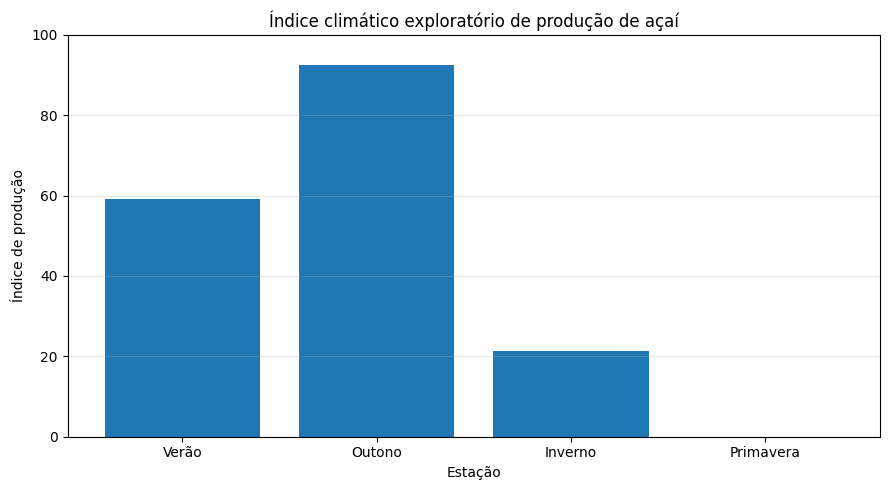

PosixPath('resultados/graficos/indice_producao_sazonal.png')

In [7]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabela_integrada["Estação"].astype(str),
    tabela_integrada["Índice de produção"]
)

plt.title("Índice climático exploratório de produção de açaí")
plt.xlabel("Estação")
plt.ylabel("Índice de produção")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

saida_indice = PASTA_GRAFICOS / "indice_producao_sazonal.png"
plt.savefig(saida_indice, dpi=300, bbox_inches="tight")
plt.show()

saida_indice

## 7. Comparação das variáveis normalizadas

As variáveis climáticas foram normalizadas para permitir comparação visual entre componentes com unidades diferentes.

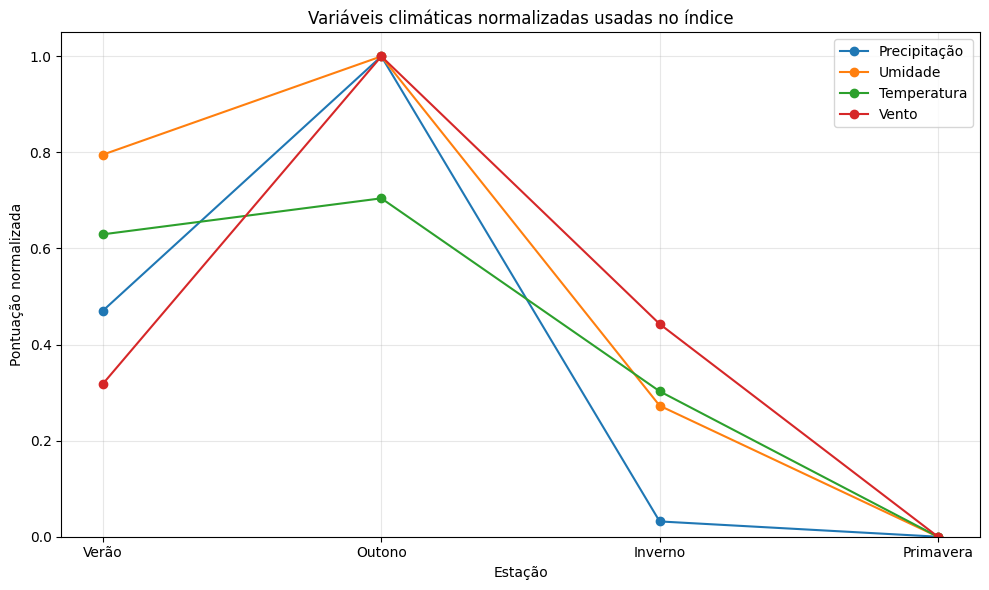

PosixPath('resultados/graficos/variaveis_normalizadas_parte3.png')

In [8]:
variaveis_normalizadas = dados[[
    "Estação",
    "precip_norm",
    "umidade_norm",
    "temp_score",
    "vento_score"
]].copy()

variaveis_normalizadas = variaveis_normalizadas.rename(columns={
    "precip_norm": "Precipitação",
    "umidade_norm": "Umidade",
    "temp_score": "Temperatura",
    "vento_score": "Vento"
})

plt.figure(figsize=(10, 6))

for coluna in ["Precipitação", "Umidade", "Temperatura", "Vento"]:
    plt.plot(
        variaveis_normalizadas["Estação"].astype(str),
        variaveis_normalizadas[coluna],
        marker="o",
        label=coluna
    )

plt.title("Variáveis climáticas normalizadas usadas no índice")
plt.xlabel("Estação")
plt.ylabel("Pontuação normalizada")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

saida_variaveis = PASTA_GRAFICOS / "variaveis_normalizadas_parte3.png"
plt.savefig(saida_variaveis, dpi=300, bbox_inches="tight")
plt.show()

saida_variaveis

## 8. Relação com a etapa de visão computacional

A Parte 2 do trabalho utilizou YOLO/Ultralytics para detectar visualmente elementos associados à produção de açaí e ao risco sanitário, especialmente cachos de açaí e barbeiros.

Como as imagens da etapa de visão computacional não foram organizadas originalmente como uma amostragem de campo sazonal, os resultados do YOLO foram interpretados principalmente como evidência da capacidade de detecção visual dos objetos de interesse.

Assim, a integração entre os resultados climáticos e a visão computacional foi realizada em caráter exploratório:

- os mapas e a tabela climática indicam variações sazonais nas condições ambientais;
- o modelo YOLO demonstra a possibilidade de identificar cachos de açaí e barbeiros em imagens;
- a comparação entre clima, produção e presença do vetor deve ser interpretada como hipótese inicial, não como relação causal comprovada.

Para uma análise mais robusta, seria necessário associar cada imagem a data, município, local de coleta e condições de campo, além de utilizar dados observados de produtividade e amostragem entomológica.

## 9. Estatísticas descritivas da tabela integrada

In [9]:
estatisticas = tabela_integrada.describe(include="all")

estatisticas

,Estação,Precipitação,Temperatura,Umidade,Vento,Índice de produção
count,4,4.000000,4.000000,4.000000,4.000000,4.000000
unique,4,NaN,NaN,NaN,NaN,NaN
top,Verão,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.351781,31.729786,58.940098,1.956769,43.292825
std,NaN,0.427636,2.592046,16.595166,0.435830,41.011384
min,NaN,0.008813,29.365915,40.330654,1.372010,0.000000
25%,NaN,0.030613,29.815807,47.692358,1.808645,15.969410
50%,NaN,0.238259,31.273869,59.553968,2.019088,40.279855
75%,NaN,0.559427,33.187848,70.801708,2.167213,67.603270


In [10]:
saida_estatisticas = PASTA_TABELAS / "estatisticas_tabela_integrada.csv"

estatisticas.to_csv(
    saida_estatisticas,
    encoding="utf-8-sig"
)

saida_estatisticas

PosixPath('resultados/tabelas/estatisticas_tabela_integrada.csv')

## 10. Download dos arquivos gerados

Os arquivos finais da Parte 3 são baixados para facilitar a inclusão no relatório e no repositório.

In [11]:
files.download(str(saida_tabela))
files.download(str(saida_estatisticas))
files.download(str(saida_indice))
files.download(str(saida_variaveis))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Síntese dos resultados

A tabela integrada e os gráficos produzidos nesta etapa permitem comparar, de forma exploratória, as condições ambientais das quatro estações.

A interpretação dos resultados deve considerar que:

1. os dados climáticos são provenientes de reanálise;
2. o índice de produção é uma construção exploratória;
3. a etapa de visão computacional identifica objetos em imagens, mas não mede diretamente produtividade agrícola;
4. a presença visual do barbeiro em imagens não equivale a estimativa populacional do vetor em campo;
5. não é possível afirmar causalidade direta entre clima, produção e presença do vetor sem dados adicionais.

Os arquivos finais gerados por este notebook são:

```text
resultados/tabelas/tabela_integrada_parte3.csv
resultados/tabelas/estatisticas_tabela_integrada.csv
resultados/graficos/indice_producao_sazonal.png
resultados/graficos/variaveis_normalizadas_parte3.png
```